# Loan Approval Prediction

## Objective
The goal of this project is to build a machine learning model that predicts whether a loan application will be approved based on socio-economic and credit-related factors.

## Phase 1: Data Loading and Exploration
In this step we import the required libraries and load the dataset to understand its structure.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

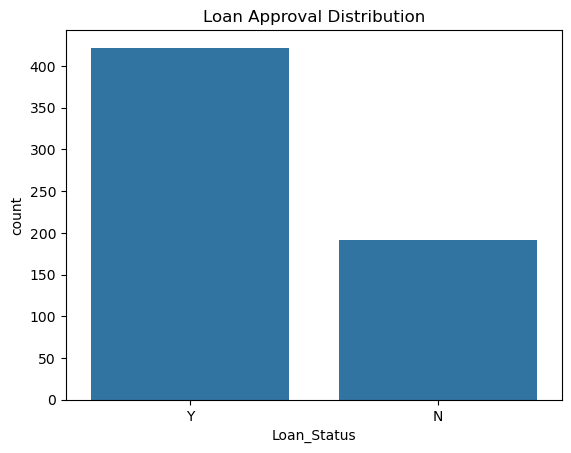

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\Admin\Spyder FirstDirectory\loan_dataset.csv")

# Display first 5 rows
print(df.head())

# Check dataset size
print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

print(df['Loan_Status'].value_counts())

sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

## Phase 1: Dataset Exploration – Insights

### Dataset Overview
The dataset contains **614 loan applications** with **13 features** describing the applicant’s socio-economic and financial background.  
The objective is to predict whether a loan application will be **approved or rejected**.

The target variable is **Loan_Status**:
- **Y** → Loan Approved  
- **N** → Loan Not Approved

---

### Dataset Structure
- **Total Rows:** 614  
- **Total Columns:** 13  

Columns in the dataset include:
- Loan_ID
- Gender
- Married
- Dependents
- Education
- Self_Employed
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History
- Property_Area
- Loan_Status

---

### Feature Types

**Categorical Features**
- Gender
- Married
- Dependents
- Education
- Self_Employed
- Property_Area
- Loan_Status

**Numerical Features**
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History

---

### Missing Values
Several columns contain missing values that must be handled during preprocessing:

- Gender
- Married
- Dependents
- Self_Employed
- LoanAmount
- Loan_Amount_Term
- Credit_History

Handling these missing values is necessary before building machine learning models.

---

### Target Variable Distribution
Loan approval distribution in the dataset:

- **Approved (Y): 422**
- **Rejected (N): 192**

This indicates that approximately **69% of applications are approved**, meaning the dataset has a **slight class imbalance** but it is still usable for classification models.

---

### Initial Observations
- Loan approval is likely influenced by **income, credit history, and loan amount**.
- Some categorical variables will need **encoding** before training models.
- Missing values must be handled during preprocessing.
- Loan_ID is an identifier and will not be useful for prediction.

## Phase 2: Data Cleaning & Preprocessing

In this phase, the dataset is prepared for machine learning models.

The following steps are performed:

1. Remove unnecessary columns
2. Handle missing values
3. Convert categorical variables
4. Fix inconsistent data formats
5. Create new useful features

These steps ensure the dataset is clean and suitable for model training.

### Step 1: Removing Unnecessary Columns

The **Loan_ID** column is simply a unique identifier for each loan application and does not contribute to prediction. Therefore, it is removed from the dataset.

In [3]:
df.drop('Loan_ID', axis=1, errors = 'ignore',  inplace=True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Step 2: Checking Missing Values

Missing values can negatively affect machine learning models.  
We check which columns contain missing values before handling them.

In [4]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Step 3: Handling Missing Values in Categorical Columns

For categorical variables such as Gender, Married, Dependents, and Self_Employed, missing values are replaced with the **mode (most frequent value)**.

In [5]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

### Step 4: Handling Missing Values in Numerical Columns

For numerical columns such as LoanAmount, Loan_Amount_Term, and Credit_History, missing values are replaced using the **median**, which is robust against outliers.

In [6]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

### Step 5: Verifying Missing Values

After filling missing values, we verify that the dataset no longer contains null values.

In [7]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [8]:
df.to_csv("loan_cleaned.csv", index=False)

### Step 6: Fixing the Dependents Column

The Dependents column contains a value **'3+'**, which must be converted into a numeric value so that machine learning models can process it.

In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

### Step 7: Feature Engineering

A new feature **TotalIncome** is created by combining ApplicantIncome and CoapplicantIncome.

This represents the **total household income available for loan repayment**, which may improve model performance.

In [10]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

df[['ApplicantIncome','CoapplicantIncome','TotalIncome']].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


## Phase 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns and relationships within the dataset.

The following visualizations will help identify factors that may influence loan approval:

- Loan approval distribution
- Loan approval by gender
- Loan approval by marital status
- Loan approval by education level
- Loan approval by self-employment status
- Income distribution
- Loan amount distribution
- Correlation matrix for numerical features

### Loan Approval Distribution

This plot shows the number of approved and rejected loan applications in the dataset.

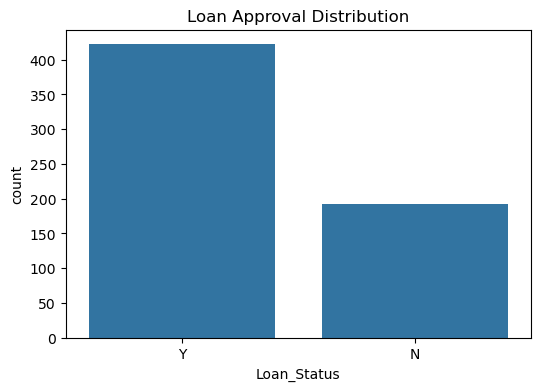

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

### Loan Approval by Gender

This visualization shows how loan approval varies between male and female applicants.

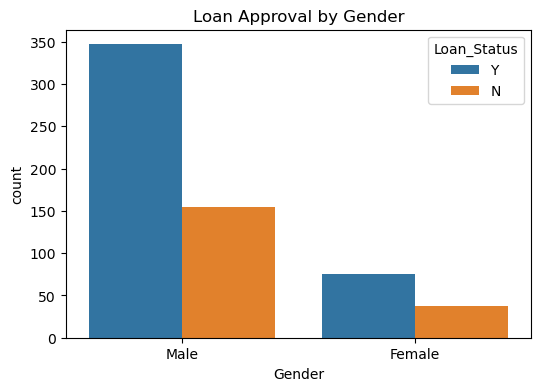

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title("Loan Approval by Gender")
plt.show()

### Loan Approval by Marital Status

This plot shows whether married or unmarried applicants receive more loan approvals.

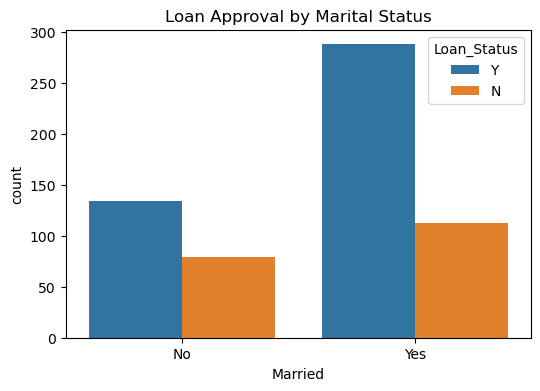

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Married', hue='Loan_Status', data=df)
plt.title("Loan Approval by Marital Status")
plt.show()

### Loan Approval by Education Level

This visualization compares loan approvals between graduate and non-graduate applicants.

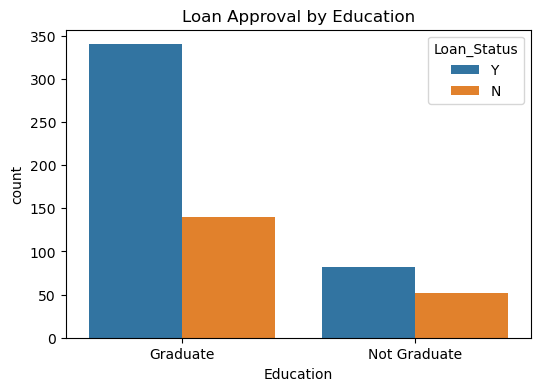

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Loan Approval by Education")
plt.show()

### Loan Approval by Self Employment

This plot compares loan approvals between self-employed and non-self-employed applicants.

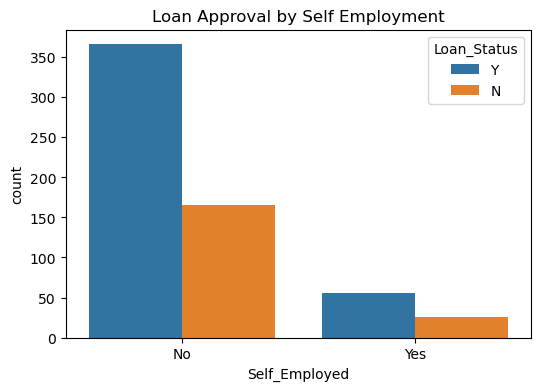

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Self_Employed', hue='Loan_Status', data=df)
plt.title("Loan Approval by Self Employment")
plt.show()

### Total Income Distribution

This histogram shows the distribution of total household income of applicants.

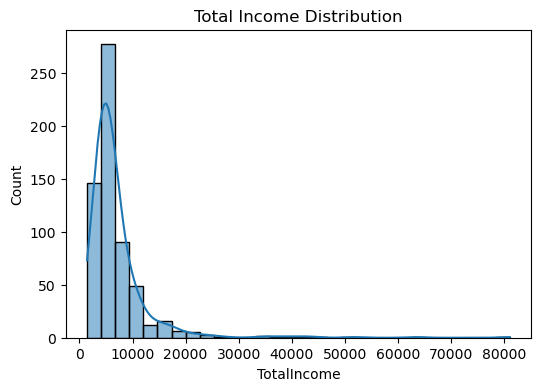

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['TotalIncome'], bins=30, kde=True)
plt.title("Total Income Distribution")
plt.show()

### Loan Amount Distribution

This histogram shows how loan amounts are distributed across the dataset.

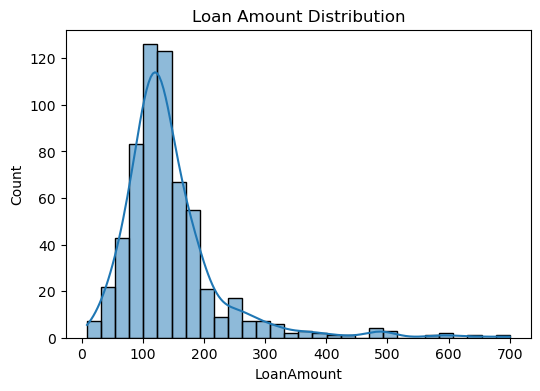

In [17]:

plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

### Correlation Matrix

The correlation heatmap shows relationships between numerical variables in the dataset.

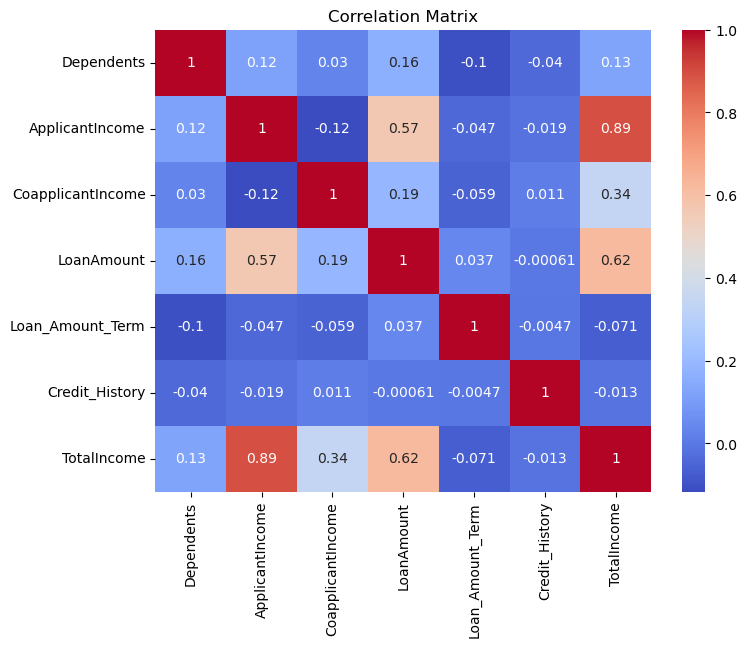

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Loan Amount vs Loan Status

This boxplot helps visualize how loan amounts differ between approved and rejected applications.

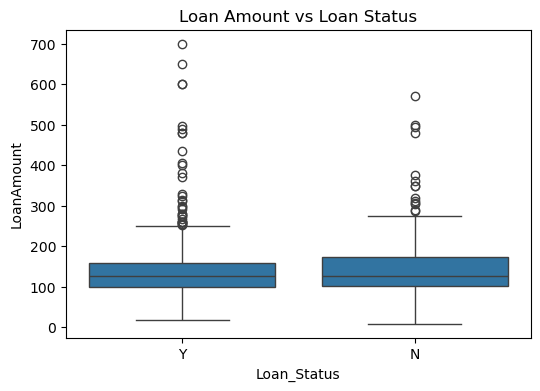

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

## Phase 4: Model Building

In this phase, machine learning models are trained to predict loan approval.

The following steps are performed:

1. Encode categorical variables
2. Split the dataset into training and testing sets
3. Train multiple classification models
4. Generate predictions

The models used in this project are:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

### Encoding Categorical Variables

Categorical features such as Gender, Married, Education, and Property_Area are converted into numerical values using Label Encoding.

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0


### Defining Features and Target Variable

The dataset is divided into:

- Features (X): Input variables used for prediction
- Target (y): Loan_Status

In [21]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

### Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression Model

In [24]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

### Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

y_pred_dt= dt_model.predict(X_test)

### Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### Support Vector Machine

In [27]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

## Phase 5: Model Evaluation

In this phase, the performance of each machine learning model is evaluated using several classification metrics.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC Score

These metrics help determine which model performs best for predicting loan approval.

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

### Logistic Regression Evaluation

In [29]:
print("Logistic Regression Performance\n")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance

Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
F1 Score: 0.8586956521739131

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



### Decision Tree Evaluation

In [30]:
print("Decision Tree Performance\n")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance

Accuracy: 0.6747967479674797
Precision: 0.75
Recall: 0.75
F1 Score: 0.75

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.53      0.53        43
           1       0.75      0.75      0.75        80

    accuracy                           0.67       123
   macro avg       0.64      0.64      0.64       123
weighted avg       0.67      0.67      0.67       123



### Random Forest Evaluation

In [31]:
print("Random Forest Performance\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance

Accuracy: 0.7723577235772358
Precision: 0.7549019607843137
Recall: 0.9625
F1 Score: 0.8461538461538461

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



### Support Vector Machine (SVM) Evaluation

In [32]:
print("SVM Performance\n")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Performance

Accuracy: 0.7967479674796748
Precision: 0.7619047619047619
Recall: 1.0
F1 Score: 0.8648648648648649

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.42      0.59        43
           1       0.76      1.00      0.86        80

    accuracy                           0.80       123
   macro avg       0.88      0.71      0.73       123
weighted avg       0.85      0.80      0.77       123



### Confusion Matrix

A confusion matrix shows how many predictions were correct and incorrect.

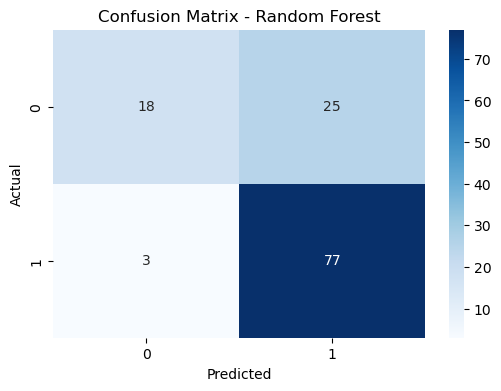

In [33]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### ROC Curve and AUC Score

The ROC curve shows the model's ability to distinguish between classes.  
The AUC score measures overall model performance.

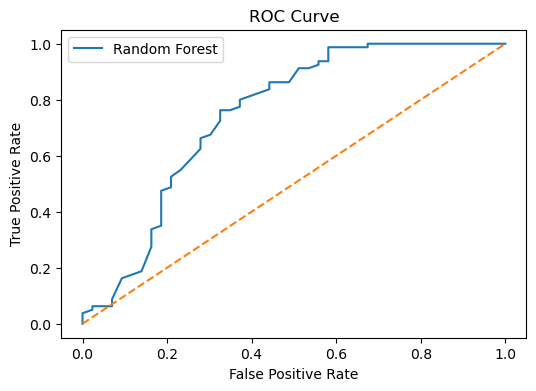

ROC-AUC Score: 0.7465116279069768


In [34]:
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

## Phase 6: Model Comparison and Interpretation

In this phase, the performance of all trained machine learning models is compared.

The goal is to identify the model that performs best in predicting loan approval.

The models evaluated are:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

Evaluation metrics used for comparison include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

In [35]:
results = []

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for name, pred in models.items():
    
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.788618,0.759615,0.9875,0.858696
1,Decision Tree,0.674797,0.750000,0.7500,0.750000
2,Random Forest,0.772358,0.754902,0.9625,0.846154
3,SVM,0.796748,0.761905,1.0000,0.864865


In [36]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]

best_model

Model             SVM
Accuracy     0.796748
Precision    0.761905
Recall            1.0
F1 Score     0.864865
Name: 3, dtype: object

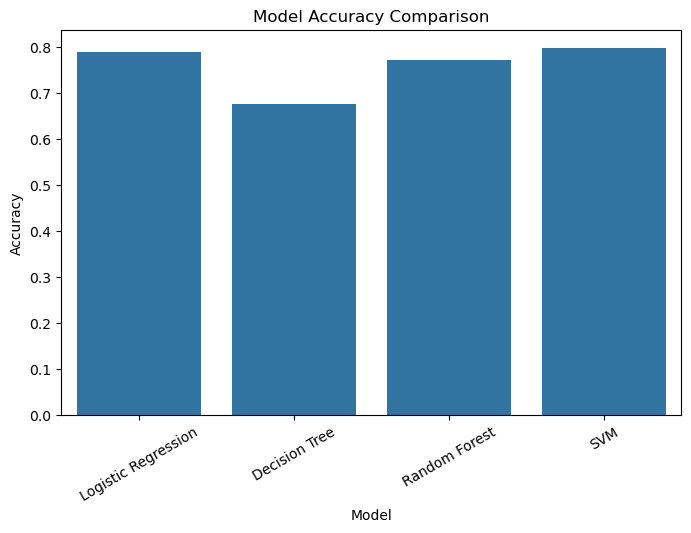

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results_df)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

## Best Performing Model

Based on the evaluation results, the **Support Vector Machine (SVM)** model achieved the highest performance among all tested models.

SVM performed well because it is effective in high-dimensional spaces and can find the optimal boundary that separates approved and rejected loan applications.

Additionally, after feature scaling, SVM can efficiently classify the data by maximizing the margin between the classes.

Therefore, the **SVM model was selected as the best-performing model for loan approval prediction**.

## Practical Application in Banking

Banks can use this predictive model to support loan approval decisions.

When a new applicant submits a loan request, the model can analyze factors such as:

- Income level
- Credit history
- Loan amount
- Employment status
- Property area

Based on these attributes, the model predicts whether the loan is likely to be approved or rejected.

Using such a model can help banks:

- Reduce manual processing time
- Improve decision consistency
- Detect high-risk applicants
- Support data-driven lending decisions

However, the model should be used as a **decision-support tool**, while final approval should still involve human oversight.